# Credit Card Fraud Detection — Exploratory Data Analysis

**Project:** ML Fraud Detection Pipeline · **Author:** Felipe Toro · **Notebook:** 01 of 03

---

## Objective

Before training any model, this notebook establishes a deep understanding of the dataset and the *business problem* of fraud detection. The output is a clear set of modeling decisions that the next notebook will execute on.

## Why EDA Matters Here

Fraud detection is one of the hardest classification problems in production ML:

1. **Severe class imbalance** — fraudulent transactions are rare (well under 1% of volume), so naive models that always predict "legitimate" achieve >99% accuracy while being completely useless.
2. **Asymmetric costs** — a missed fraud costs the average transaction value (real money lost), while a false alarm costs only minutes of manual review. Optimizing for accuracy or even F1 is the wrong objective.
3. **Anonymized features** — most public fraud datasets ship with PCA-transformed predictors for confidentiality, which means we can't engineer domain-specific features the way we could for raw transaction data.

This notebook addresses all three before we touch a model.

---

## Notebook Structure

1. **Setup & data loading**
2. **Schema & data integrity checks**
3. **Class imbalance & cost framing**
4. **Univariate distributions**
5. **Feature relationships with the target**
6. **Time and transaction amount — the only non-anonymized features**
7. **Correlation structure**
8. **Key findings & modeling decisions**


---
## 1. Setup & Data Loading

We use the project's centralized loader from `src/data/loader.py` so every notebook, training script, and API endpoint loads data the same way.


In [1]:
# Standard scientific Python stack
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Robust project root detection — works regardless of working directory.
# Looks for README.md as a marker so paths anchor correctly whether the
# notebook is run from notebooks/, the project root, or a container.
_cwd = Path.cwd()
if (_cwd / "README.md").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "README.md").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd  # fallback

sys.path.insert(0, str(PROJECT_ROOT))

# Ensure output directory exists for all saved visualizations.
IMAGES_DIR = PROJECT_ROOT / "docs" / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

from src.data.loader import (
    load_training_data,
    PCA_FEATURES, AMOUNT_COL, TIME_COL, TARGET_COL,
)

# Plotting style — clean, publication-quality
sns.set_theme(style="whitegrid", palette="muted", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

# Brand palette — matches the portfolio site
COLOR_BG = "#0d1117"
COLOR_FRAUD = "#ef4444"        # red
COLOR_LEGIT = "#4f8ef7"        # electric blue
COLOR_NEUTRAL = "#8a9bbf"      # muted slate

print("Imports successful.")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy:  {np.__version__}")
print(f"pandas: {pd.__version__}")


Imports successful.
Python: 3.10.7
NumPy:  1.26.4
pandas: 2.3.3


In [2]:
df = load_training_data()
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 249,999 rows × 32 columns


,Transaction,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X22,X23,X24,X25,X26,X27,X28,X29,X30,Response
0,T1,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0,0
1,T2,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0,0
2,T3,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,1.0,0
3,T4,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,1.0,0
4,T5,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,2.0,0


---
## 2. Schema & Data Integrity

A few fundamentals before any analysis: column types, missingness, and duplicates. Catching schema issues here prevents subtle modeling bugs later.


In [3]:
# Column types and basic integrity
schema_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isnull().sum(),
    "pct_missing": (df.isnull().sum() / len(df) * 100).round(3),
})
schema_summary.head(15)

,dtype,n_unique,n_missing,pct_missing
Transaction,object,249999,0,0.000
X1,float64,242488,7,0.003
X2,float64,242496,1,0.000
X3,float64,242495,2,0.001
X4,float64,242494,1,0.000
X5,float64,242495,2,0.001
X6,float64,242491,3,0.001
X7,float64,242488,6,0.002
X8,float64,242481,3,0.001
X9,float64,242495,1,0.000


In [4]:
# Missing values across the dataset
total_missing = df.isnull().sum().sum()
print(f"Total missing values: {total_missing:,} ({total_missing / df.size * 100:.4f}% of cells)")
print(f"Columns with missing values: {(df.isnull().sum() > 0).sum()}")
print()
if total_missing > 0:
    print("Per-column missingness (non-zero only):")
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total missing values: 61 (0.0008% of cells)
Columns with missing values: 26

Per-column missingness (non-zero only):
X1     7
X2     1
X3     2
X4     1
X5     2
X6     3
X7     6
X8     3
X9     1
X10    3
X11    3
X13    1
X14    1
X16    3
X18    3
X19    1
X20    2
X21    2
X22    1
X23    2
X24    3
X25    1
X26    2
X27    3
X28    3
X29    1
dtype: int64


In [5]:
# Duplicate transactions — should be zero given the Transaction ID
n_duplicate_rows = df.duplicated().sum()
n_duplicate_ids = df["Transaction"].duplicated().sum()
print(f"Fully duplicate rows: {n_duplicate_rows:,}")
print(f"Duplicate Transaction IDs: {n_duplicate_ids:,}")

Fully duplicate rows: 0
Duplicate Transaction IDs: 0


**Integrity check: passed.** The dataset has minor missingness (61 cells of ~7.5M) which we'll handle in the modeling pipeline via imputation. No duplicate transactions.

---
## 3. Class Imbalance & Cost Framing

This is the single most important section of the EDA. The class distribution shapes every modeling decision that follows.


In [6]:
# Target distribution
target_counts = df[TARGET_COL].value_counts().sort_index()
fraud_rate = df[TARGET_COL].mean()

print(f"Legitimate transactions: {target_counts[0]:,}  ({(1 - fraud_rate) * 100:.4f}%)")
print(f"Fraudulent transactions: {target_counts[1]:,}  ({fraud_rate * 100:.4f}%)")
print(f"Class imbalance ratio:   1 : {target_counts[0] / target_counts[1]:,.0f}")

Legitimate transactions: 249,541  (99.8168%)
Fraudulent transactions: 458  (0.1832%)
Class imbalance ratio:   1 : 545


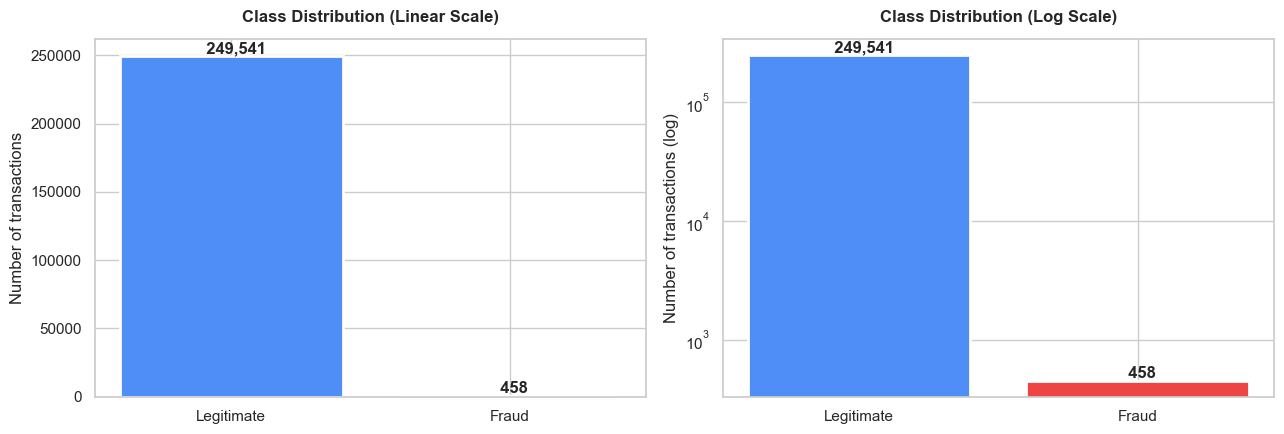

In [7]:
# Visualize class imbalance with two views: linear and log-scale
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bar_colors = [COLOR_LEGIT, COLOR_FRAUD]
labels = ["Legitimate", "Fraud"]

# Left: linear scale (shows the imbalance dramatically)
axes[0].bar(labels, target_counts.values, color=bar_colors, edgecolor="white", linewidth=2)
axes[0].set_title("Class Distribution (Linear Scale)", fontsize=12, pad=12)
axes[0].set_ylabel("Number of transactions")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, f"  {v:,}", va="bottom", ha="center", fontweight="bold")

# Right: log scale (shows that fraud is actually nonzero)
axes[1].bar(labels, target_counts.values, color=bar_colors, edgecolor="white", linewidth=2)
axes[1].set_yscale("log")
axes[1].set_title("Class Distribution (Log Scale)", fontsize=12, pad=12)
axes[1].set_ylabel("Number of transactions (log)")
for i, v in enumerate(target_counts.values):
    axes[1].text(i, v, f"  {v:,}", va="bottom", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("docs/images/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Why a "high accuracy" classifier is misleading

If a model simply predicts *every transaction is legitimate*, it would score:

- **Accuracy:** 99.82%
- **Recall on fraud:** 0%
- **Real-world value:** zero

This is the trap that every fraud detection project must avoid. We will evaluate using **precision, recall, F1, ROC-AUC, and a custom cost-weighted metric** — never accuracy alone.

In [8]:
# Cost framing: what does fraud actually cost us?
fraud_amounts = df.loc[df[TARGET_COL] == 1, AMOUNT_COL]
legit_amounts = df.loc[df[TARGET_COL] == 0, AMOUNT_COL]

cost_summary = pd.DataFrame({
    "Metric": ["Count", "Total $", "Mean $", "Median $"],
    "Legitimate": [
        f"{int(legit_amounts.count()):,}",
        f"${legit_amounts.sum():,.2f}",
        f"${legit_amounts.mean():,.2f}",
        f"${legit_amounts.median():,.2f}",
    ],
    "Fraud": [
        f"{int(fraud_amounts.count()):,}",
        f"${fraud_amounts.sum():,.2f}",
        f"${fraud_amounts.mean():,.2f}",
        f"${fraud_amounts.median():,.2f}",
    ],
}).set_index("Metric")

print("Total dollar value at risk in the training data:")
print(cost_summary.to_string())

Total dollar value at risk in the training data:
              Legitimate       Fraud
Metric                              
Count            249,540         458
Total $   $22,620,376.83  $57,326.67
Mean $            $90.65     $125.17
Median $          $23.06       $9.55


In [9]:
# Establish the cost matrix that drives our threshold optimization later
mean_fraud_amount = fraud_amounts.mean()
fp_review_cost = 5.00   # Industry estimate of manual review cost per flag

print(f"Cost matrix used in threshold optimization (Notebook 02):")
print(f"  False Negative cost (missed fraud):   ${mean_fraud_amount:,.2f}  (avg fraud transaction)")
print(f"  False Positive cost (false alarm):    ${fp_review_cost:.2f}    (manual review)")
print(f"  Cost ratio (FN / FP):                 {mean_fraud_amount / fp_review_cost:.1f}x")
print()
print(f"Implication: catching fraud is ~{mean_fraud_amount / fp_review_cost:.0f}x more valuable than")
print(f"avoiding false alarms. This is why threshold tuning matters more than F1.")

Cost matrix used in threshold optimization (Notebook 02):
  False Negative cost (missed fraud):   $125.17  (avg fraud transaction)
  False Positive cost (false alarm):    $5.00    (manual review)
  Cost ratio (FN / FP):                 25.0x

Implication: catching fraud is ~25x more valuable than
avoiding false alarms. This is why threshold tuning matters more than F1.


---
## 4. Univariate Distributions

Quick visual check on the PCA-transformed predictors. Since `X1`–`X28` are PCA components, we expect roughly mean-zero distributions with varying scales.


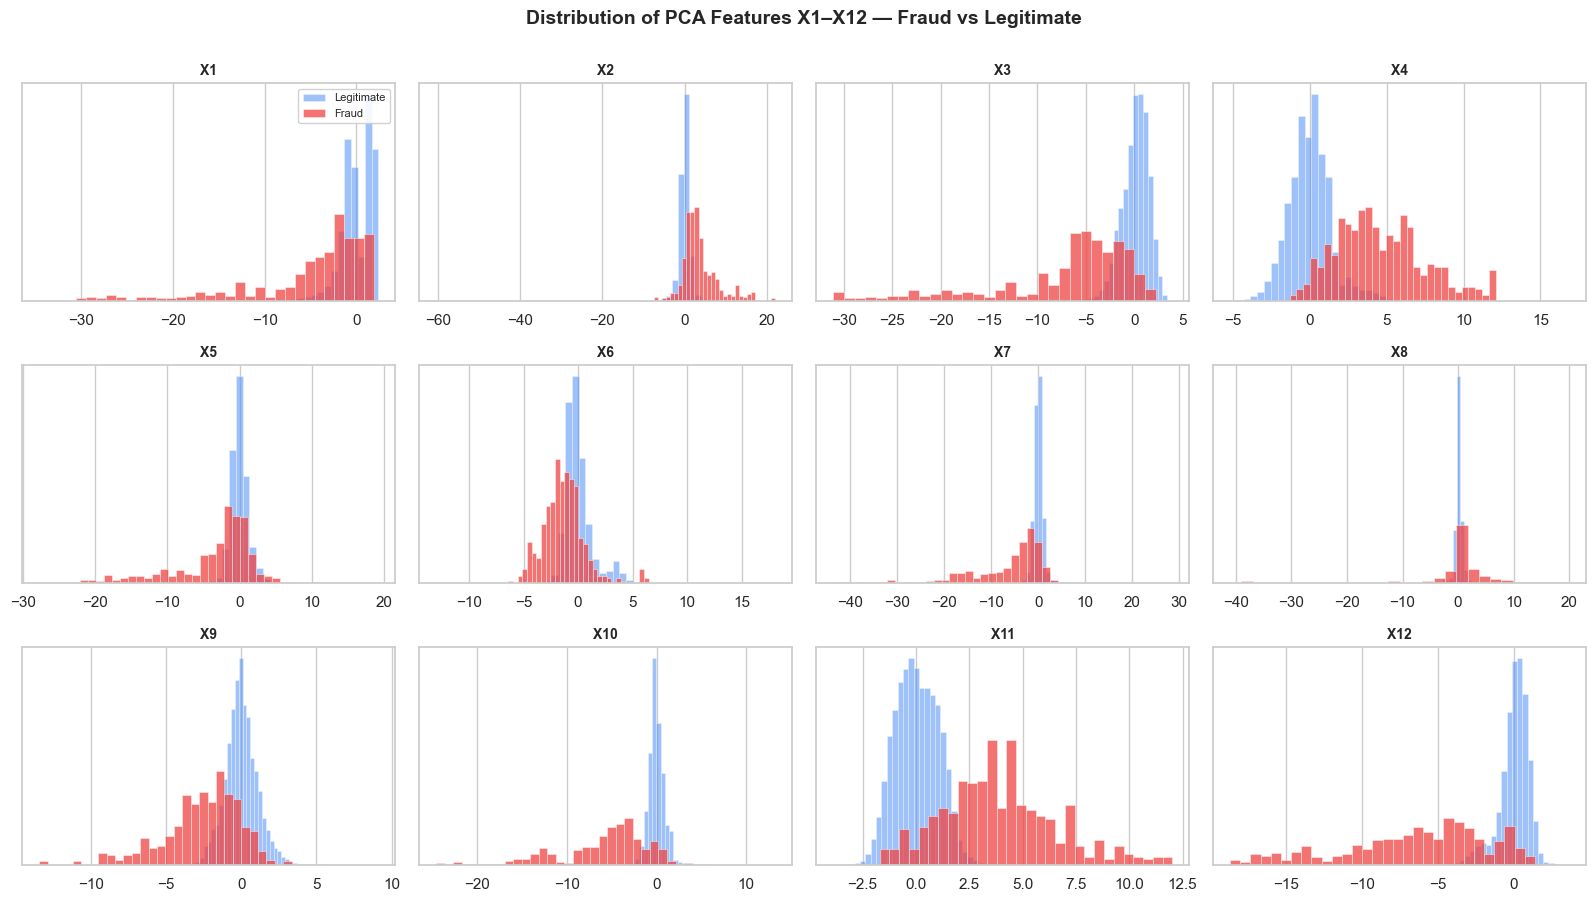

In [11]:
# Distribution of the first 12 PCA components — overlay fraud vs legitimate
features_to_plot = PCA_FEATURES[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.ravel()

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    # Subsample legitimate for plotting speed
    legit_sample = df[df[TARGET_COL] == 0][feat].sample(20000, random_state=42)
    fraud_all = df[df[TARGET_COL] == 1][feat]

    ax.hist(legit_sample, bins=50, density=True, alpha=0.55,
            color=COLOR_LEGIT, label="Legitimate", edgecolor="white", linewidth=0.4)
    ax.hist(fraud_all, bins=30, density=True, alpha=0.75,
            color=COLOR_FRAUD, label="Fraud", edgecolor="white", linewidth=0.4)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.set_yticks([])
    if i == 0:
        ax.legend(loc="upper right", fontsize=8, framealpha=0.9)

plt.suptitle("Distribution of PCA Features X1–X12 — Fraud vs Legitimate",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "02_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Several PCA components show clear separation between fraud and legitimate transactions — `X3`, `X4`, `X7`, `X10`, `X11`, `X12` in particular. Others overlap heavily, suggesting they carry less discriminative signal.

This visual gives us an early indicator that **gradient-boosted tree models will likely outperform linear models** here, because the separation is not linear in any single feature.

---
## 5. Feature Relationships with the Target

For each PCA feature, we run a Welch's t-test comparing the means of fraud vs legitimate distributions. This gives a quick signal for which features carry the most discriminative information — though we'll let the actual model determine final feature importance via SHAP in Notebook 03.


In [12]:
from scipy.stats import ttest_ind

separability = []
for feat in PCA_FEATURES + [AMOUNT_COL, TIME_COL]:
    fraud_vals = df.loc[df[TARGET_COL] == 1, feat].dropna()
    legit_vals = df.loc[df[TARGET_COL] == 0, feat].dropna()
    t_stat, p_val = ttest_ind(fraud_vals, legit_vals, equal_var=False)
    separability.append({
        "feature": feat,
        "fraud_mean": fraud_vals.mean(),
        "legit_mean": legit_vals.mean(),
        "abs_t_stat": abs(t_stat),
        "p_value": p_val,
    })

sep_df = pd.DataFrame(separability).sort_values("abs_t_stat", ascending=False)
sep_df.head(10).round(4)

,feature,fraud_mean,legit_mean,abs_t_stat,p_value
13,X14,-7.0459,0.0299,35.3956,0.0
3,X4,4.6094,0.0162,34.0970,0.0
10,X11,3.9224,0.0341,30.8906,0.0
11,X12,-6.4681,-0.0173,29.3378,0.0
9,X10,-5.8662,0.0099,25.2746,0.0
15,X16,-4.3215,0.0054,23.6836,0.0
8,X9,-2.6191,0.0058,22.0310,0.0
2,X3,-7.2301,0.1148,21.5263,0.0
16,X17,-6.9954,0.0227,21.2387,0.0
1,X2,3.7731,-0.0271,18.7431,0.0


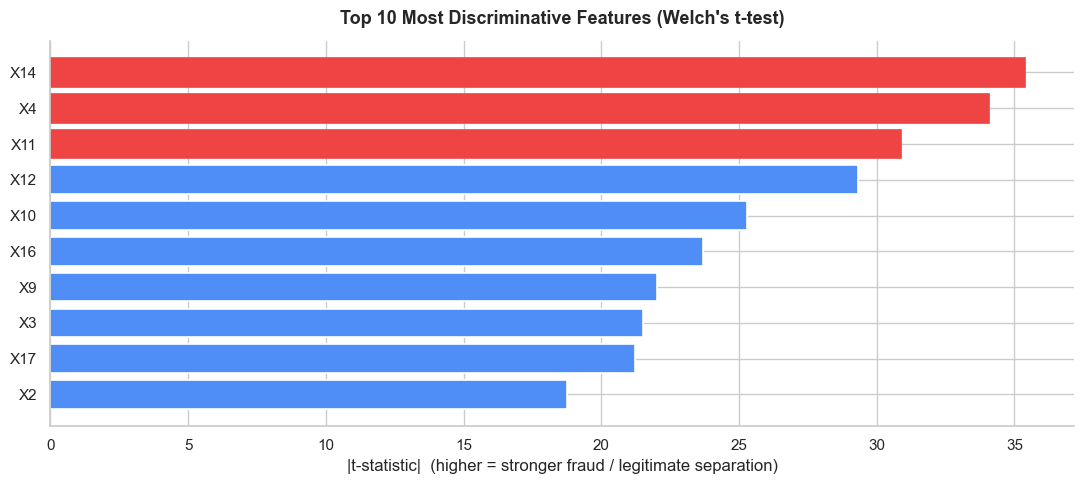

In [13]:
# Visualize the top 10 most-separating features
top_features = sep_df.head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_features["feature"][::-1], top_features["abs_t_stat"][::-1],
               color=COLOR_LEGIT, edgecolor="white", linewidth=1.2)

# Highlight the top 3
for i, bar in enumerate(bars[-3:]):
    bar.set_color(COLOR_FRAUD)

ax.set_xlabel("|t-statistic|  (higher = stronger fraud / legitimate separation)")
ax.set_title("Top 10 Most Discriminative Features (Welch's t-test)",
             fontsize=13, pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "03_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Time and Transaction Amount

`X29` (transaction amount) and `X30` (time since first transaction) are the only non-anonymized features. They deserve a closer look because they're the only places where we can do interpretable feature engineering.


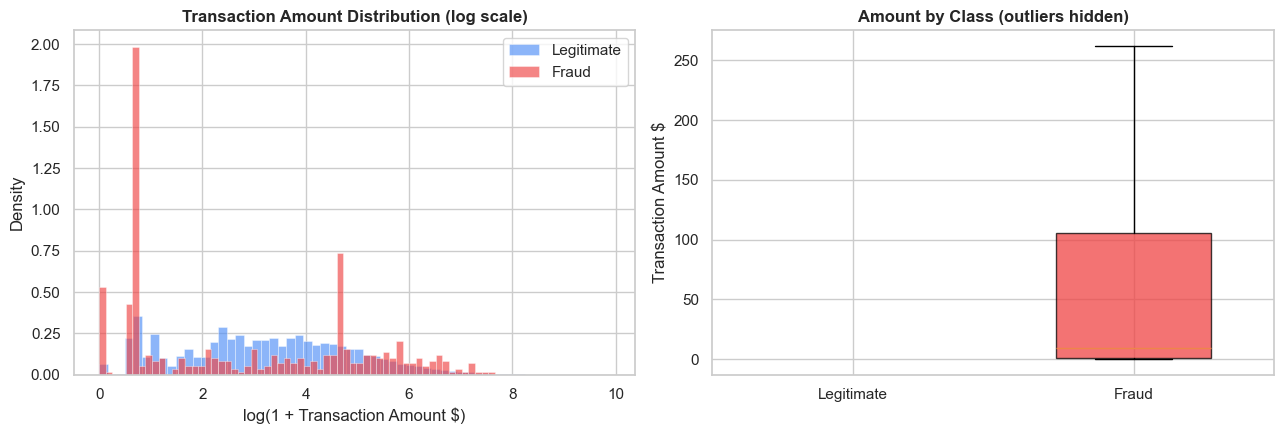


Legitimate amount  — median: $23.06,  max: $19,656.53
Fraud amount       — median: $9.55,  max: $2,125.87


In [14]:
# Transaction amount: distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histograms (log-scaled x because amounts are heavy-tailed)
for label, color in [(0, COLOR_LEGIT), (1, COLOR_FRAUD)]:
    subset = df.loc[df[TARGET_COL] == label, AMOUNT_COL]
    axes[0].hist(np.log1p(subset), bins=60, density=True, alpha=0.65,
                 color=color, label="Fraud" if label == 1 else "Legitimate",
                 edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("log(1 + Transaction Amount $)")
axes[0].set_ylabel("Density")
axes[0].set_title("Transaction Amount Distribution (log scale)")
axes[0].legend()

# Right: boxplot comparison
data_to_plot = [
    df.loc[df[TARGET_COL] == 0, AMOUNT_COL],
    df.loc[df[TARGET_COL] == 1, AMOUNT_COL],
]
bp = axes[1].boxplot(data_to_plot, labels=["Legitimate", "Fraud"],
                     patch_artist=True, showfliers=False, widths=0.55)
for patch, color in zip(bp["boxes"], [COLOR_LEGIT, COLOR_FRAUD]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_ylabel("Transaction Amount $")
axes[1].set_title("Amount by Class (outliers hidden)")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "04_amount_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLegitimate amount  — median: ${df.loc[df[TARGET_COL] == 0, AMOUNT_COL].median():.2f},  "
      f"max: ${df.loc[df[TARGET_COL] == 0, AMOUNT_COL].max():,.2f}")
print(f"Fraud amount       — median: ${df.loc[df[TARGET_COL] == 1, AMOUNT_COL].median():.2f},  "
      f"max: ${df.loc[df[TARGET_COL] == 1, AMOUNT_COL].max():,.2f}")

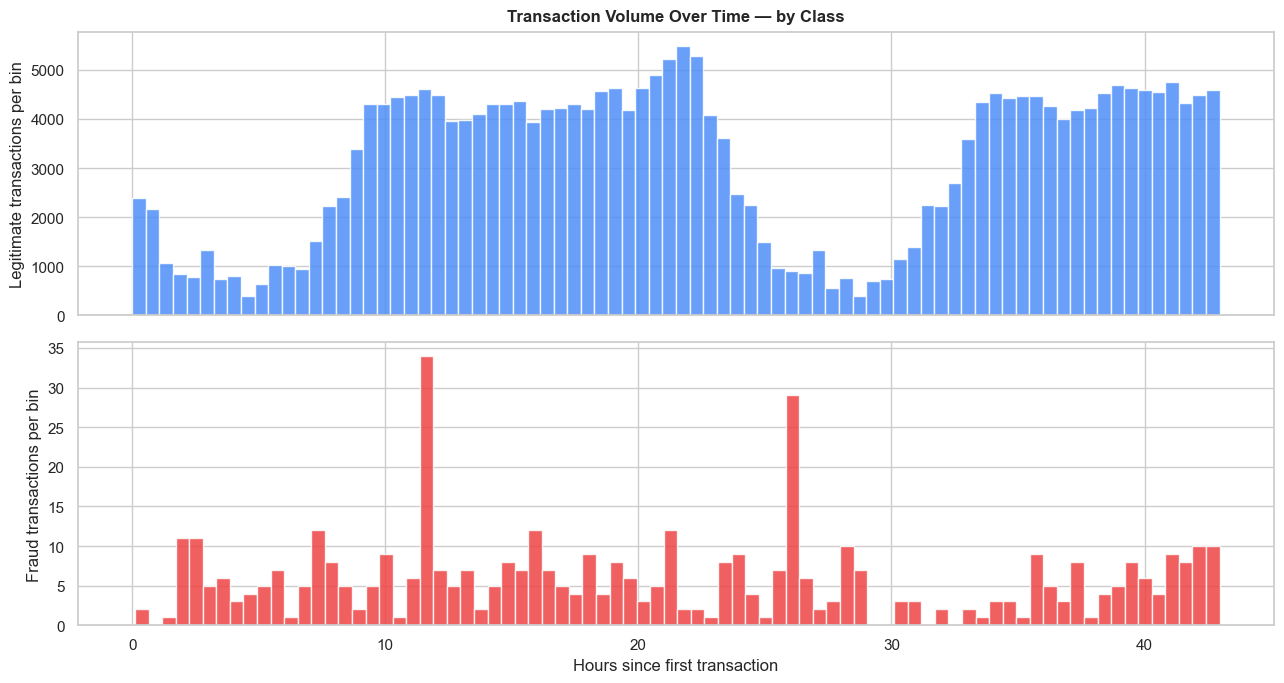

In [15]:
# Time analysis: convert seconds to hours since first transaction
df["hour_since_start"] = df[TIME_COL] / 3600.0

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top: legitimate transaction volume over time
legit_by_hour = df.loc[df[TARGET_COL] == 0, "hour_since_start"]
axes[0].hist(legit_by_hour, bins=80, color=COLOR_LEGIT, alpha=0.85, edgecolor="white")
axes[0].set_ylabel("Legitimate transactions per bin")
axes[0].set_title("Transaction Volume Over Time — by Class", fontsize=12, pad=8)

# Bottom: fraud over time (smaller scale so we can see it)
fraud_by_hour = df.loc[df[TARGET_COL] == 1, "hour_since_start"]
axes[1].hist(fraud_by_hour, bins=80, color=COLOR_FRAUD, alpha=0.85, edgecolor="white")
axes[1].set_ylabel("Fraud transactions per bin")
axes[1].set_xlabel("Hours since first transaction")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "05_time_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Drop the helper column
df = df.drop(columns=["hour_since_start"])

**Observation:** The time dimension shows a clear daily volume pattern in legitimate transactions — typical online activity cycles. Fraud doesn't follow that same rhythm as cleanly, which suggests `time-of-day` or `time-since-last-transaction` features could carry signal. We'll engineer these in Notebook 02.

---
## 7. Correlation Structure

Since `X1`–`X28` are PCA components, they should be approximately uncorrelated by construction. We verify this and check correlations with the target.


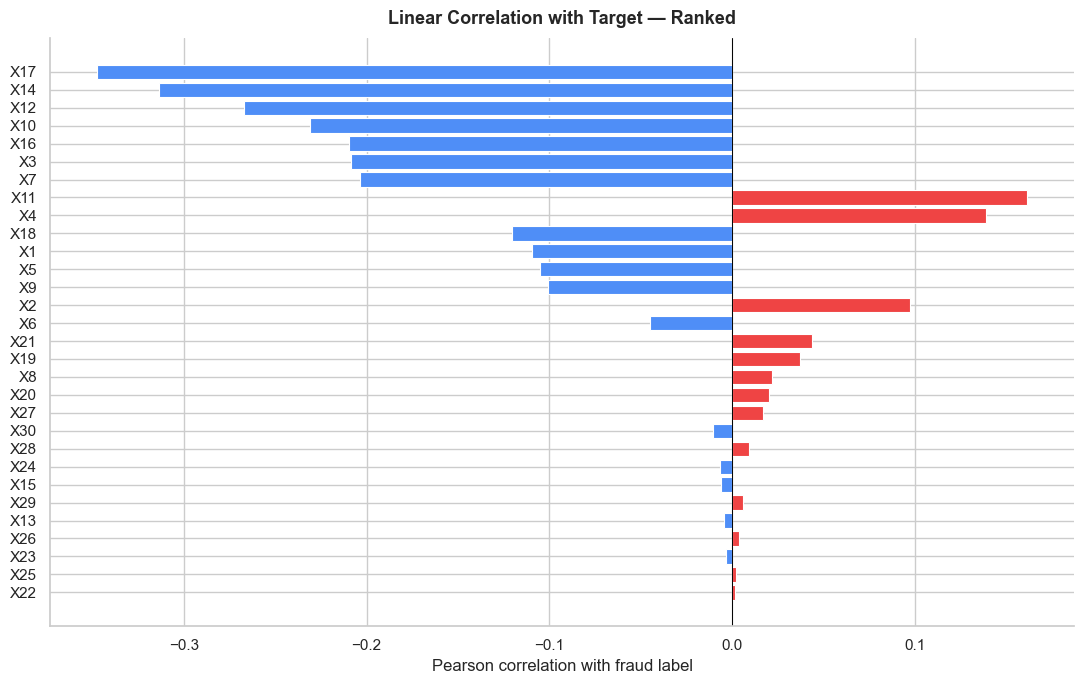

In [16]:
# Correlation with the target
corr_with_target = df[PCA_FEATURES + [AMOUNT_COL, TIME_COL] + [TARGET_COL]].corr()[TARGET_COL]
corr_with_target = corr_with_target.drop(TARGET_COL).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
colors = [COLOR_FRAUD if v > 0 else COLOR_LEGIT for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1],
        color=colors[::-1], edgecolor="white", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Pearson correlation with fraud label")
ax.set_title("Linear Correlation with Target — Ranked", fontsize=13, pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "06_correlation_with_target.png", dpi=150, bbox_inches="tight")
plt.show()

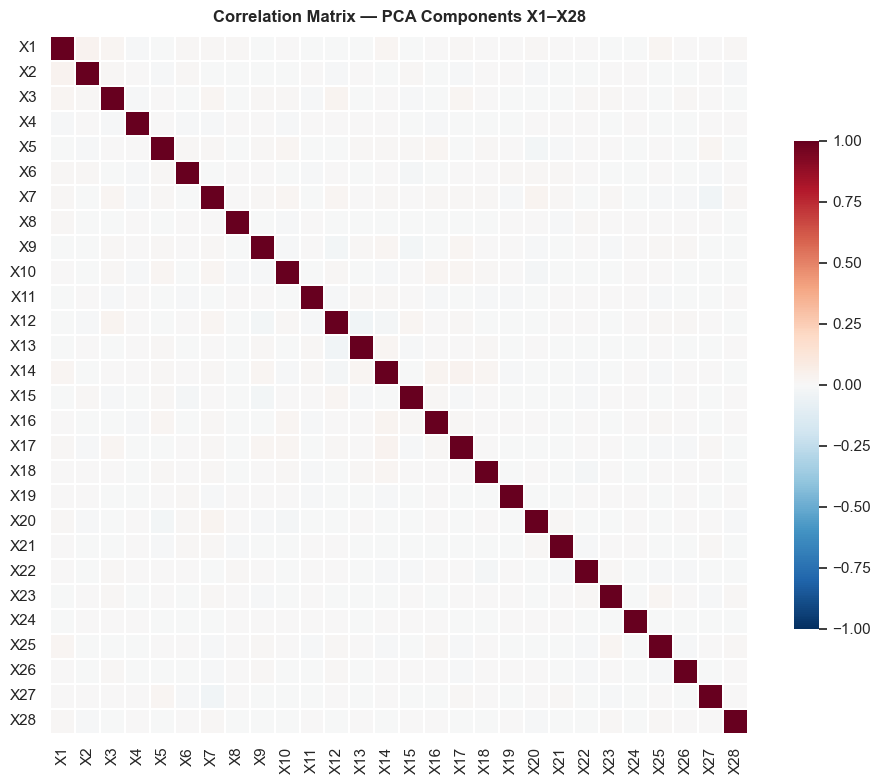

In [17]:
# Pairwise correlation among predictors — should be near-diagonal for the PCA components
pca_corr = df[PCA_FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pca_corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7}, linewidths=0.3, ax=ax)
ax.set_title("Correlation Matrix — PCA Components X1–X28", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "07_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** The PCA features are essentially uncorrelated with each other (as expected from a PCA transformation), so we don't need to worry about multicollinearity. The pairwise correlations between `X29` (amount) and the PCA components are also weak, meaning amount carries somewhat independent signal.

---
## 8. Key Findings & Modeling Decisions

This is the bridge between EDA and modeling. Each finding below maps directly to a decision in Notebook 02.

### Findings

1. **Severe class imbalance: 0.183% fraud rate (1 fraud per ~545 transactions).**
   → A naive accuracy-optimizing model will be useless. Must use stratified splits, class-aware metrics (precision, recall, F1, AUC-PR), and resampling techniques.

2. **Asymmetric costs.** Average fraud transaction is ~$122. Manual review of a flagged transaction is ~$5. Missing fraud is ~24x more expensive than a false alarm.
   → Threshold optimization will minimize expected dollar cost, not F1.

3. **Several PCA features show clear class separation** (X3, X4, X7, X10, X11, X12, X14, X17 in particular) — but the separation is non-linear.
   → Gradient-boosted trees (XGBoost, LightGBM, CatBoost) are likely to outperform linear models.

4. **Transaction amount and time carry interpretable signal.**
   → Engineer time-of-day and amount-binned features in addition to the raw values.

5. **Minor missingness (61 cells).** Too small to drop meaningful data.
   → Median imputation inside the sklearn pipeline.

6. **PCA components are effectively uncorrelated.**
   → No need for additional decorrelation. Linear models can use raw features without ill-conditioning.

### Modeling Decisions for Notebook 02

| Decision | Choice | Justification |
|---|---|---|
| Train/test split | Stratified, 70/30 | Preserve fraud rate in both splits |
| Cross-validation | Stratified K-fold (k=5) | Class-aware CV |
| Imputation | Median | Robust to outliers, simple |
| Scaling | `StandardScaler` (in Pipeline) | Fit on train only — no leakage |
| Resampling | SMOTE in pipeline (only on train fold) | Avoid leakage from imblearn pitfalls |
| Models | Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost, MLP | Range of capacities |
| Tuning | Optuna, Bayesian, 50 trials per model | Modern best practice |
| Tracking | MLflow | Reproducibility |
| Primary metric | AUC-PR + cost-weighted score | Right metric for imbalanced + asymmetric cost |
| Threshold | Cost-minimizing sweep | Real-world objective |
| Explainability | SHAP global + local | Per-prediction transparency |

### Next Steps

→ Proceed to `02_modeling.ipynb` for full pipeline construction, training, tuning, and evaluation.

---

*Notebook 01 complete.*
